# A Transfer Learning and Optimized CNN Based Intrusion Detection System for Internet of Vehicles

This is the code for the paper entitled "**A Transfer Learning and Optimized CNN Based Intrusion Detection System for Internet of Vehicles**" published in **IEEE International Conference on Communications (IEEE ICC)**, doi=[10.1109/ICC45855.2022.9838780](https://ieeexplore.ieee.org/document/9838780).  
Authors: Li Yang (lyang339@uwo.ca) and Abdallah Shami (Abdallah.Shami@uwo.ca)  
Organization: The Optimized Computing and Communications (OC2) Lab, ECE Department, Western University

**Notebook 2: CNN Model Development**  
Aims:  
&nbsp; 1): Generate training and test images  
&nbsp; 2): Construct CNN models (a CNN model by own, Xception, VGG16, VGG19, Resnet, Inception, InceptionResnet)  
&nbsp; 3): Tune the hyperparameters of CNN models (hyperparameter optimization)


## Import libraries


In [3]:
# Core Python
import os
import time
import random
import math
import warnings
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms

# Extra pretrained models (e.g., InceptionResNetV2, Xception)
import timm

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Hyperparameter optimization
from hyperopt import hp, fmin, tpe, rand, STATUS_OK, Trials

# Suppress warnings
warnings.filterwarnings("ignore")

# Reproducibility (optional but recommended)
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

## PyTorch GPU Sanity Check


In [ ]:
# Check for GPU availability and show device info
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    print(f"✅ GPU is available: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"Device Count: {torch.cuda.device_count()}")
else:
    print("⚠️ GPU not available. Using CPU instead.")

# Set default tensor type (optional, if we want to default to GPU when available)
# torch.set_default_tensor_type(torch.FloatTensor if device.type == 'cpu' else torch.cuda.FloatTensor)

✅ GPU is available: NVIDIA GeForce RTX 3060
CUDA Version: 12.8
Device Count: 1


## Generate Training and Test Images


In [5]:
# Constants
TARGET_SIZE = (224, 224)
INPUT_SIZE = (3, 224, 224)  # PyTorch uses CHW format
BATCHSIZE = 32  # 128 or 32

# Define image transformations (normalize to [0,1] using ToTensor)
transform = transforms.Compose(
    [
        transforms.Resize(TARGET_SIZE),
        transforms.ToTensor(),  # scales image pixels to [0, 1]
    ]
)

# Load datasets from directory structure
train_dataset = datasets.ImageFolder(root="./train_224/", transform=transform)
test_dataset = datasets.ImageFolder(root="./test_224/", transform=transform)

# DataLoaders for batching and shuffling
train_loader = DataLoader(
    train_dataset, batch_size=BATCHSIZE, shuffle=True, num_workers=4
)
validation_loader = DataLoader(
    test_dataset, batch_size=BATCHSIZE, shuffle=False, num_workers=4
)

# Get number of classes (for output layer later)
num_classes = len(train_dataset.classes)

### Define the image plotting functions


In [6]:
class LossHistory:
    def __init__(self):
        self.losses = {"batch": [], "epoch": []}
        self.accuracy = {"batch": [], "epoch": []}
        self.val_loss = {"batch": [], "epoch": []}
        self.val_acc = {"batch": [], "epoch": []}

    def record_batch(self, train_loss, train_acc, val_loss=None, val_acc=None):
        self.losses["batch"].append(train_loss)
        self.accuracy["batch"].append(train_acc)
        if val_loss is not None:
            self.val_loss["batch"].append(val_loss)
        if val_acc is not None:
            self.val_acc["batch"].append(val_acc)

    def record_epoch(self, train_loss, train_acc, val_loss, val_acc):
        self.losses["epoch"].append(train_loss)
        self.accuracy["epoch"].append(train_acc)
        self.val_loss["epoch"].append(val_loss)
        self.val_acc["epoch"].append(val_acc)

    def loss_plot(self, loss_type="epoch"):
        iters = range(len(self.losses[loss_type]))
        plt.figure()
        plt.plot(iters, self.losses[loss_type], "g", label="train loss")
        if loss_type == "epoch":
            plt.plot(iters, self.accuracy[loss_type], "r", label="train acc")
            plt.plot(iters, self.val_acc[loss_type], "b", label="val acc")
            plt.plot(iters, self.val_loss[loss_type], "k", label="val loss")
        plt.grid(True)
        plt.xlabel(loss_type)
        plt.ylabel("acc-loss")
        plt.legend(loc="upper right")
        plt.show()

In [7]:
# Instantiate tracker
history_this = LossHistory()

# Construct CNN models


### Model 1: a CNN model by own (baseline)


#### Defining Model Architecture


In [8]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=5):
        super(CustomCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),  # input: (3,224,224)
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),  # output: (64,112,112)
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),  # output: (128,56,56)
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
        )

        self.global_pool = nn.AdaptiveAvgPool2d(
            (1, 1)
        )  # Replaces GlobalAveragePooling2D
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.global_pool(x)
        x = self.classifier(x)
        return x

#### Training Function


In [9]:
def train_model(
    model,
    train_loader,
    val_loader,
    num_classes,
    epochs=1,
    save_path="./artifacts/model_own.pth",
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    best_val_acc = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = correct / total

        # Validation
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / val_total

        history_this.record_epoch(train_loss, train_acc, val_loss, val_acc)

        print(
            f"Epoch [{epoch+1}/{epochs}] - "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
        )

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)

    print(f"Best Validation Accuracy: {best_val_acc:.4f}")

Epoch [1/1] - Train Loss: 0.1437, Train Acc: 0.9483 | Val Loss: 0.0250, Val Acc: 0.9937
Best Validation Accuracy: 0.9937


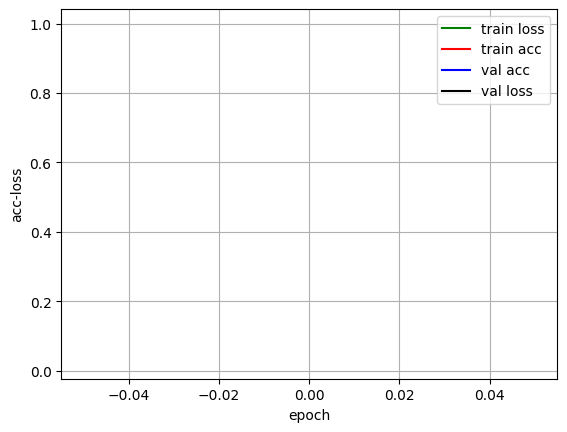

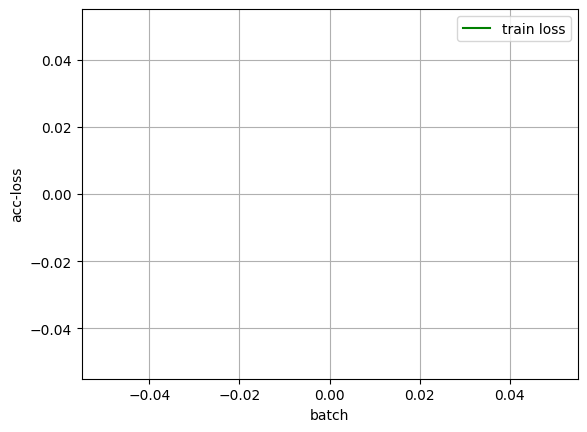

In [10]:
model = CustomCNN(num_classes=5)
train_model(
    model,
    train_loader,
    validation_loader,
    num_classes=5,
    epochs=1,
    save_path="./artifacts/model_own.pth",
)

# Plot results
history_this.loss_plot("epoch")
history_this.loss_plot("batch")  # If you also log batch-level metrics
plt.show()

Validation accuracy of a CNN by own: 99.884%


### Model 2: Xception


In [11]:
def train_xception(
    num_classes,
    train_loader,
    val_loader,
    epochs=1,
    save_path="./artifacts/xception.pth",
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Load pretrained Xception from timm
    model_fine_tune = timm.create_model("xception", pretrained=True)

    # Freeze first 131 layers (approximate: timm models use named children instead of index)
    freeze_until = 131
    children = list(model_fine_tune.children())
    count = 0
    for child in children:
        count += 1
        if count < freeze_until:
            for param in child.parameters():
                param.requires_grad = False

    # Replace classification head
    model_fine_tune.reset_classifier(num_classes)

    model = model_fine_tune.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    best_val_acc = 0

    for epoch in range(epochs):
        model.train()
        train_loss, correct, total = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss /= len(train_loader.dataset)
        train_acc = correct / total

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / val_total

        history_this.record_epoch(train_loss, train_acc, val_loss, val_acc)

        print(
            f"[{epoch+1}/{epochs}] Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}"
        )

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)

    print(f"Best Validation Accuracy: {best_val_acc:.4f}")

[1/1] Train Loss: 0.0687, Acc: 0.9855 | Val Loss: 0.0020, Acc: 0.9997
Best Validation Accuracy: 0.9997


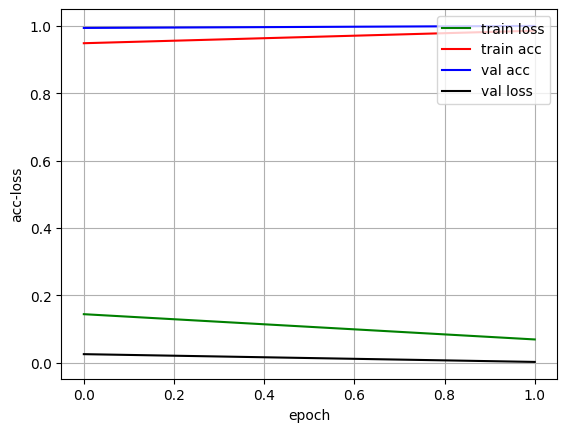

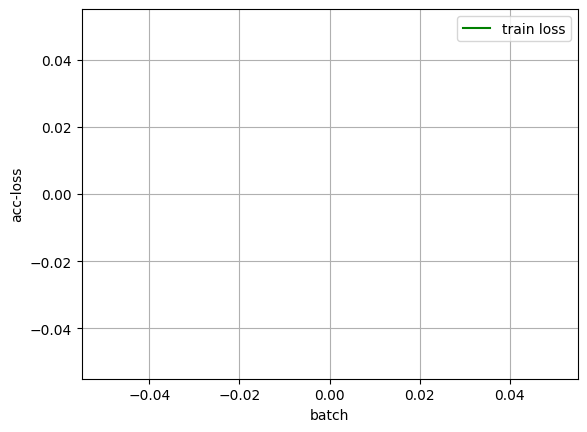

In [ ]:
train_xception(
    num_classes=5, train_loader=train_loader, val_loader=validation_loader, epochs=1
)
# Plot results
history_this.loss_plot("epoch")
history_this.loss_plot("batch")
plt.show()

Validation accuracy of Xception: 100.0%


### Model 3: VGG16


In [39]:
def train_vgg16(
    train_loader,
    val_loader,
    num_classes=5,
    epochs=1,
    save_path="./artifacts/vgg16.pth",
    freeze_until=15,
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Load pretrained VGG16
    model_fine_tune = models.vgg16(pretrained=True)

    # Freeze early layers
    for idx, param in enumerate(model_fine_tune.features.parameters()):
        if idx < freeze_until:
            param.requires_grad = False

    # Replace classifier head
    model_fine_tune.classifier = nn.Sequential(
        nn.Linear(25088, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(256, num_classes),
    )

    model = model_fine_tune.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    best_val_acc = 0

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, total = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        train_loss /= len(train_loader.dataset)
        train_acc = train_correct / total

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / val_total

        history_this.record_epoch(train_loss, train_acc, val_loss, val_acc)

        print(
            f"[{epoch+1}/{epochs}] Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}"
        )

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)

    print(f"Best Validation Accuracy: {best_val_acc:.4f}")

[1/1] Train Loss: 1.6352, Acc: 0.8605 | Val Loss: 0.6303, Acc: 0.8544
Best Validation Accuracy: 0.8544


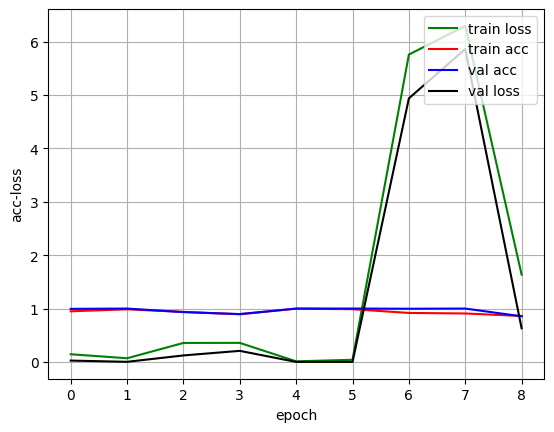

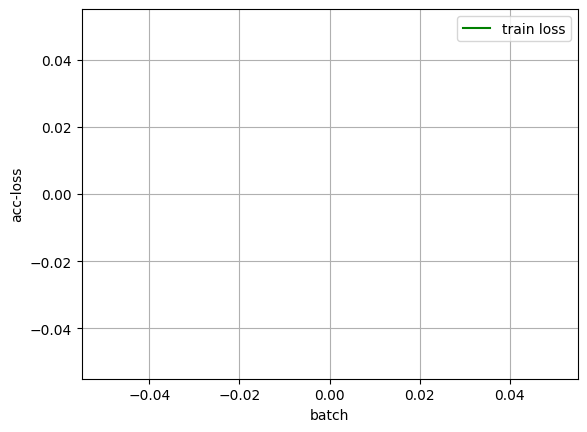

In [ ]:
train_vgg16(
    num_classes=5, train_loader=train_loader, val_loader=validation_loader, epochs=1
)
# Plot results
history_this.loss_plot("epoch")
history_this.loss_plot("batch")
plt.show()

Validation accuracy of VGG16: 100.0%


### Model 4: VGG19


In [15]:
def train_vgg19(
    num_classes,
    train_loader,
    val_loader,
    epochs=1,
    save_path="./artifacts/vgg19.pth",
    freeze_until=19,
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Load pretrained VGG19
    model_fine_tune = models.vgg19(pretrained=True)

    # Freeze early convolutional layers (based on number of conv layers)
    for idx, param in enumerate(model_fine_tune.features.parameters()):
        if idx < freeze_until:
            param.requires_grad = False

    # Replace classifier head
    model_fine_tune.classifier = nn.Sequential(
        nn.Linear(25088, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(256, num_classes),
    )

    model = model_fine_tune.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    best_val_acc = 0

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, total = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            train_correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss /= len(train_loader.dataset)
        train_acc = train_correct / total

        # Validation phase
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / val_total

        history_this.record_epoch(train_loss, train_acc, val_loss, val_acc)

        print(
            f"[{epoch+1}/{epochs}] Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}"
        )

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)

    print(f"Best Validation Accuracy: {best_val_acc:.4f}")

[1/1] Train Loss: 0.3568, Acc: 0.8923 | Val Loss: 0.2073, Acc: 0.8965
Best Validation Accuracy: 0.8965


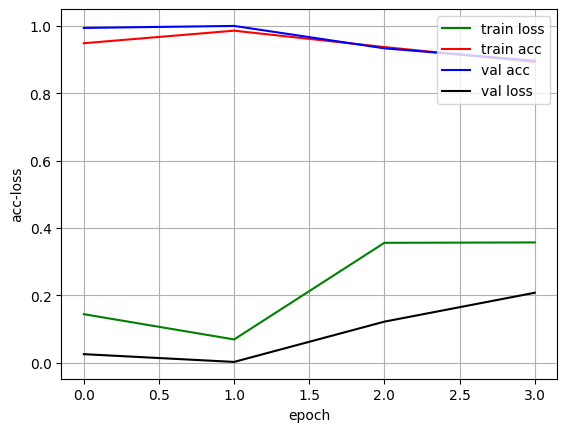

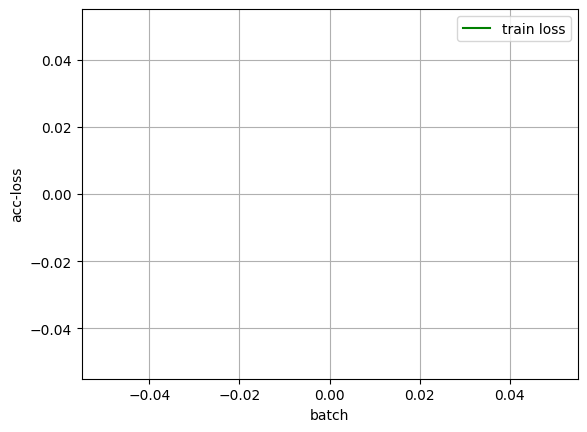

In [16]:
train_vgg19(
    num_classes=5, train_loader=train_loader, val_loader=validation_loader, epochs=1
)
history_this.loss_plot("epoch")
history_this.loss_plot("batch")
plt.show()

Validation accuracy of VGG19: 100.0%


### Model 5: ResNet


In [17]:
def train_resnet50(
    num_classes,
    train_loader,
    val_loader,
    epochs=1,
    save_path="./artifacts/resnet50.pth",
    freeze_until=120,
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Load pretrained ResNet50
    model_fine_tune = models.resnet50(pretrained=True)

    # Freeze first `freeze_until` layers (counted by named parameters)
    child_counter = 0
    for name, param in model_fine_tune.named_parameters():
        if child_counter < freeze_until:
            param.requires_grad = False
        else:
            param.requires_grad = True
        child_counter += 1

    # Replace final fully connected layer
    in_features = model_fine_tune.fc.in_features
    model_fine_tune.fc = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(256, num_classes),
    )

    model = model_fine_tune.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    best_val_acc = 0

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, total = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            train_correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_loss /= len(train_loader.dataset)
        train_acc = train_correct / total

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / val_total

        history_this.record_epoch(train_loss, train_acc, val_loss, val_acc)

        print(
            f"[{epoch+1}/{epochs}] Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}"
        )

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)

    print(f"Best Validation Accuracy: {best_val_acc:.4f}")

[1/1] Train Loss: 0.0109, Acc: 0.9969 | Val Loss: 0.0000, Acc: 1.0000
Best Validation Accuracy: 1.0000


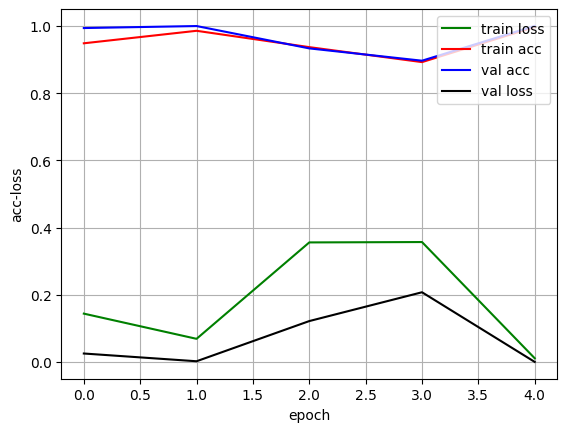

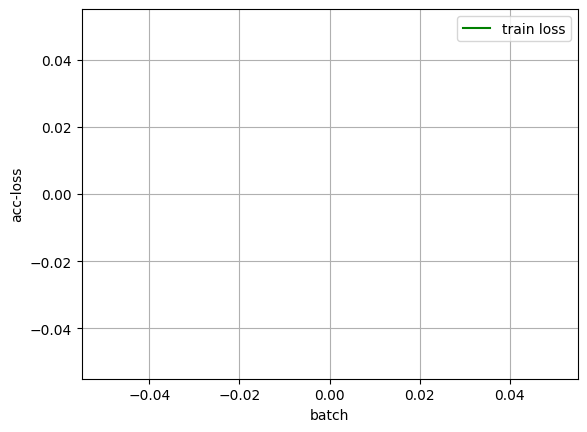

In [18]:
train_resnet50(
    num_classes=5, train_loader=train_loader, val_loader=validation_loader, epochs=1
)
history_this.loss_plot("epoch")
history_this.loss_plot("batch")
plt.show()

Validation accuracy of Resnet: 98.652%


### Model 6: Inception


In [27]:
def train_inception_v3(
    num_classes,
    train_loader,
    val_loader,
    epochs=1,
    save_path="./artifacts/inception_v3.pth",
    freeze_until=35,
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Load pretrained InceptionV3
    # model_fine_tune = models.inception_v3(
    #     pretrained=True, aux_logits=True
    # )  # aux_logits=False disables side branch

    model_fine_tune = models.inception_v3(weights=None, aux_logits=False)
    model_fine_tune = models.inception_v3(aux_logits=False)
    state_dict = models.inception_v3(weights="DEFAULT", aux_logits=True).state_dict()
    model_fine_tune.load_state_dict(state_dict, strict=False)

    # Freeze early layers
    child_counter = 0
    for name, param in model_fine_tune.named_parameters():
        if child_counter < freeze_until:
            param.requires_grad = False
        else:
            param.requires_grad = True
        child_counter += 1

    # Replace the final fully connected layer
    in_features = model_fine_tune.fc.in_features
    model_fine_tune.fc = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(256, num_classes),
    )

    model = model_fine_tune.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    best_val_acc = 0

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, total = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            train_correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss /= len(train_loader.dataset)
        train_acc = train_correct / total

        # Validation phase
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / val_total

        history_this.record_epoch(train_loss, train_acc, val_loss, val_acc)

        print(
            f"[{epoch+1}/{epochs}] Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}"
        )

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)

    print(f"Best Validation Accuracy: {best_val_acc:.4f}")

[1/1] Train Loss: 0.0403, Acc: 0.9878 | Val Loss: 0.0003, Acc: 0.9998
Best Validation Accuracy: 0.9998


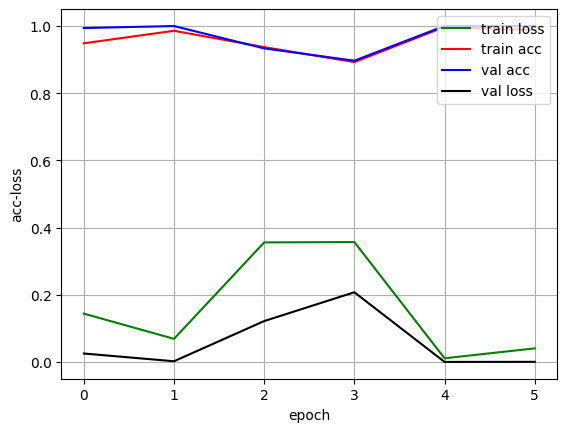

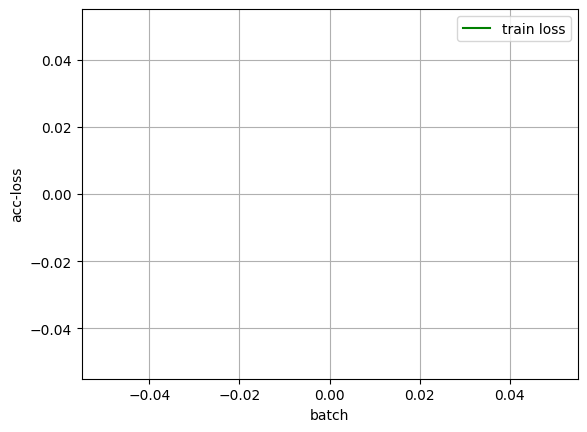

In [28]:
train_inception_v3(
    num_classes=5, train_loader=train_loader, val_loader=validation_loader, epochs=1
)
history_this.loss_plot("epoch")
history_this.loss_plot("batch")
plt.show()

Validation accuracy of Inception: 100.0%


### Model 7: InceptionResnet


In [ ]:
import timm
import torch
import torch.nn as nn
import torch.optim as optim


def train_inceptionresnetv2(
    num_classes,
    train_loader,
    val_loader,
    epochs=5,
    save_path="./artifacts/inceptionresnetv2.pth",
    freeze_until=500,
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Build model with a proper 1536→num_classes head
    model = timm.create_model(
        "inception_resnet_v2",
        pretrained=True,
        num_classes=num_classes,  # sets final Linear(1536, num_classes)
        drop_rate=0.5,  # adds a dropout before the head
    )

    # Freeze early layers by parameter index
    for idx, (name, param) in enumerate(model.named_parameters()):
        param.requires_grad = idx >= freeze_until

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    # Only pass the unfrozen parameters to the optimizer
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=2
    )

    best_val_acc = 0.0

    for epoch in range(1, epochs + 1):
        # Training
        model.train()
        running_loss, running_corrects, running_total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            running_corrects += (preds == labels).sum().item()
            running_total += labels.size(0)

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = running_corrects / running_total

        # Validation
        model.eval()
        val_loss, val_corrects, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                preds = outputs.argmax(dim=1)
                val_corrects += (preds == labels).sum().item()
                val_total += labels.size(0)

        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_acc = val_corrects / val_total

        scheduler.step(epoch_val_loss)
        history_this.record_epoch(
            epoch_train_loss, epoch_train_acc, epoch_val_loss, epoch_val_acc
        )

        print(
            f"[{epoch}/{epochs}] "
            f"Train Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.4f} | "
            f"Val   Loss: {epoch_val_loss:.4f}, Acc: {epoch_val_acc:.4f}"
        )

        # Save best
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            torch.save(model.state_dict(), save_path)

    print(f"✅ Best Validation Accuracy: {best_val_acc:.4f}")

[1/1] Train Loss: 0.0284, Acc: 0.9942 | Val   Loss: 5.2188, Acc: 0.9620
✅ Best Validation Accuracy: 0.9620


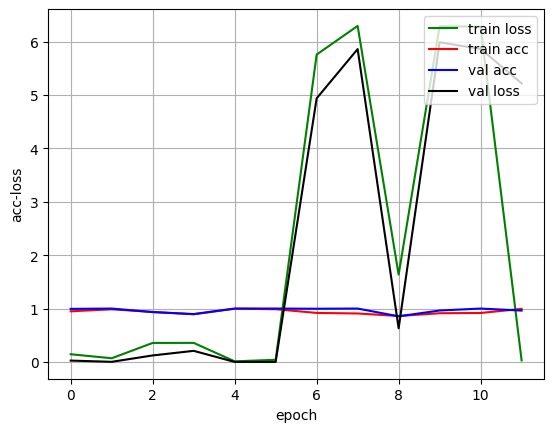

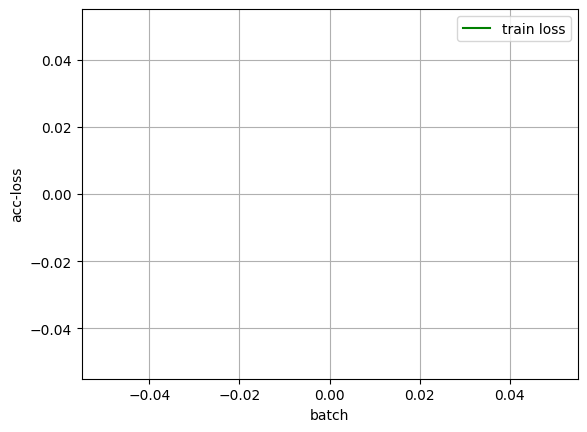

In [46]:
train_inceptionresnetv2(
    num_classes=5, train_loader=train_loader, val_loader=validation_loader, epochs=1
)
history_this.loss_plot("epoch")
history_this.loss_plot("batch")
plt.show()

Validation accuracy of InceptionResnet: 99.993%


# Hyperparameter Optimization

Use VGG16 as an example.

Tuned hyperparameters of CNN:

1. The number of frozen layers
2. The number of epochs
3. Early stop patience
4. Learning rate
5. Dropout rate

Hyperparameter optimization methods:

1. Random search
2. Bayesian optimization - Tree Parzen Estimator(BO-TPE)


#### PyTorch-Compatible VGG16 Training Function with Dynamic Parameters


In [31]:
def train_vgg16_with_params(
    num_classes,
    frozen,
    epochs,
    patience,
    lr,
    dropout_rate,
    save_path="./artifacts/VGG16_best.pth",
    verbose=0,
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = models.vgg16(pretrained=True)

    # Freeze first N layers
    for idx, param in enumerate(model.features.parameters()):
        param.requires_grad = idx >= frozen

    # Replace classifier
    model.classifier = nn.Sequential(
        nn.Linear(25088, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(dropout_rate),
        nn.Linear(256, num_classes),
    )

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_val_acc = 0
    no_improve = 0

    for epoch in range(epochs):
        model.train()
        train_loss, correct, total = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_acc = correct / total

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in validation_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        val_acc = val_correct / val_total

        if verbose:
            print(
                f"Epoch {epoch+1}/{epochs} - Train Acc: {train_acc:.4f} - Val Acc: {val_acc:.4f}"
            )

        # Early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    return best_val_acc

#### Evaluation Function


In [32]:
def evaluate_vgg16_model(saved_model_path="./artifacts/VGG16_best.pth"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = models.vgg16(pretrained=False)
    model.classifier = nn.Sequential(
        nn.Linear(25088, 256), nn.ReLU(inplace=True), nn.Dropout(0.5), nn.Linear(256, 5)
    )
    model.load_state_dict(torch.load(saved_model_path))
    model = model.to(device)
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in validation_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    return acc

#### Objective Function for hyperopt


In [33]:
def objective(params):
    # Parse params
    frozen = int(params["frozen"])
    epochs = int(params["epochs"])
    patience = int(params["patience"])
    lr = float(params["lr"])
    dropout_rate = float(params["dropout_rate"])

    acc = train_vgg16_with_params(
        num_classes=5,
        frozen=frozen,
        epochs=epochs,
        patience=patience,
        lr=lr,
        dropout_rate=dropout_rate,
        verbose=0,
    )

    print(f"Test Accuracy: {acc:.4f} with params: {params}")
    return {"loss": -acc, "status": STATUS_OK}

#### Define Search Space and Run Optimization


In [ ]:
space = {
    "frozen": hp.quniform("frozen", 15, 18, 1),
    "epochs": hp.quniform("epochs", 5, 21, 5),
    "patience": hp.quniform("patience", 2, 4, 1),
    "lr": hp.quniform("lr", 0.001, 0.006, 0.001),
    "dropout_rate": hp.quniform("dropout_rate", 0.3, 0.6, 0.1),
}

# Bayesian Optimization (TPE)
t1 = time.time()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=10)
print("TPE Best Params:", best)
t2 = time.time()
print("TPE Time Elapsed:", t2 - t1)

# Random Search
t1 = time.time()
best = fmin(fn=objective, space=space, algo=rand.suggest, max_evals=10)
print("Random Best Params:", best)
t2 = time.time()
print("Random Time Elapsed:", t2 - t1)

#### Retrain with Best Found Params (Example)


In [ ]:
# train_vgg16_with_params(
#     num_classes=5,
#     frozen=16,
#     epochs=15,
#     patience=3,
#     lr=0.002,
#     dropout_rate=0.6,
#     verbose=1,
# )